# Strategy Comparison — All Models

Runs every portfolio strategy in a single shared environment for unified comparison.

**Strategies (rolling, realistic — no look-ahead bias):**
Equal Weight · 60/40 Benchmark · Sample Portfolio · Naive RP · ERC RP · Markowitz · Black-Litterman · Factor Investing · FSO (γ=3.0)

**Metrics:** Ann. Return (CAGR), Volatility, Sharpe, Sortino, Max DD, Skewness, Kurtosis, Final Value, Recovery time per crisis

---
### Methodological notes
- **Annualized Return** is geometric CAGR: `(product of (1+r))^(12/T) - 1`.
- **Sortino Ratio** uses downside deviation vs the monthly risk-free rate.
- **Naive RP** weights estimated from the first `LOOKBACK` months only — no look-ahead bias.
- **ERC RP** weights always sum to 1 (no leverage/vol-targeting scaling).
- **Markowitz** constrained to exactly `VOL_TARGET` (10% ann. vol) at each rebalance.
- **FSO** constrained to the same `VOL_TARGET` (10% ann. vol) for a fair comparison with Markowitz.
- **60/40 Benchmark** uses VEU (international equity, 60%) + BND (40%).


In [45]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.optimize as sco
from sklearn.covariance import LedoitWolf
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore')

BASE = Path('../../data')
with open('../../markets.json') as f:
    config = json.load(f)

market_name        = list(config['markets'].keys())[0]
initial_investment = config['initial_investment']

LOOKBACK        = 36
REBAL_THRESHOLD = 0.05
VOL_TARGET      = 0.10

CRISES = [
    ('2008-09', '2009-06', 'GFC'),
    ('2020-02', '2020-04', 'COVID'),
    ('2022-01', '2022-12', 'Rate Hikes'),
]

PALETTE = {
    'Equal Weight'    : "#033b1b",
    '60/40 Benchmark' : '#8896A5',
    'Sample Portfolio': '#884400',
    'Naive RP'        : '#F6C90E',
    'ERC RP'          : "#245F3C",
    'Markowitz'       : '#6a0DAD',
    'Black-Litterman' : '#1A202C',
    'Factor Investing': "#3798E7",
    'FSO (y=3.0)'     : '#DD6B20',
}

plt.rcParams.update({
    'figure.facecolor': '#fff', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.color': '#CBD5E0',
    'font.family': 'sans-serif',
})
print(f'Market: {market_name}  |  Initial investment: ${initial_investment:,.0f}')
print(f'Lookback: {LOOKBACK}m  |  Rebal threshold: {REBAL_THRESHOLD*100:.0f}%  |  Vol target: {VOL_TARGET*100:.0f}%')


Market: primary_total_market  |  Initial investment: $1,000
Lookback: 36m  |  Rebal threshold: 5%  |  Vol target: 10%


In [21]:
returns = pd.read_csv(BASE / f'{market_name}_returns_monthly.csv',
                      index_col=0, parse_dates=True)
assets  = returns.columns.tolist()
N       = len(assets)

rf_data           = pd.read_csv(BASE / 'risk_free_monthly.csv',
                                index_col=0, parse_dates=True)
rf_data           = rf_data.reindex(returns.index, method='ffill')
annual_rf_series  = rf_data['rf_annual']
monthly_rf_series = rf_data['rf_monthly']

print(f'Returns : {returns.index[0].date()} -> {returns.index[-1].date()} ({len(returns)} months)')
print(f'Assets  : {assets}')
print(f'RF mean : {annual_rf_series.mean()*100:.3f}% annual')
returns.describe().round(4)


Returns : 2007-05-01 -> 2025-12-01 (224 months)
Assets  : ['BND', 'GLD', 'TIP', 'TLT', 'VEU', 'VGT']
RF mean : 1.415% annual


,BND,GLD,TIP,TLT,VEU,VGT
count,224.0000,224.0000,224.0000,224.0000,224.0000,224.0000
mean,0.0026,0.0091,0.0030,0.0033,0.0050,0.0141
std,0.0135,0.0490,0.0174,0.0411,0.0520,0.0570
min,-0.0419,-0.1614,-0.0811,-0.1249,-0.2276,-0.1795
25%,-0.0046,-0.0217,-0.0058,-0.0238,-0.0239,-0.0184
50%,0.0026,0.0047,0.0038,0.0021,0.0076,0.0194
75%,0.0104,0.0422,0.0120,0.0252,0.0345,0.0502
max,0.0476,0.1279,0.0650,0.1423,0.1517,0.1465


In [22]:
def months_to_recover(ret, cs, ce):
    cum  = (1 + ret).cumprod()
    pre  = cum.loc[:cs]
    if pre.empty: return None
    pk   = pre.max()
    tw   = cum.loc[cs:ce]
    if tw.empty: return None
    td   = tw.idxmin()
    post = cum.loc[td:]
    rec  = post[post >= pk]
    if rec.empty: return None
    return len(cum.loc[td:rec.index[0]]) - 1


def compute_stats(ret, label, rf_m, rf_a, init_inv):
    ar   = ((1 + ret).cumprod().iloc[-1] ** (12 / len(ret)) - 1) * 100  # true geometric CAGR
    av   = ret.std()  * np.sqrt(12) * 100
    sr   = (ret.mean() - rf_m) * 12 / (ret.std() * np.sqrt(12))
    cum  = (1 + ret).cumprod()
    mdd  = ((cum - cum.cummax()) / cum.cummax()).min() * 100
    cumr = (cum.iloc[-1] - 1) * 100
    skw  = scipy_stats.skew(ret.dropna())
    krt  = scipy_stats.kurtosis(ret.dropna())
    fv   = init_inv * cum.iloc[-1]
    # Sortino: downside deviation uses ALL periods (not just down months)
    # Formula: sqrt(mean(min(r - rf, 0)^2)) * sqrt(12)  [Sortino & van der Meer, 1991]
    shortfalls = np.minimum(ret - rf_m, 0)
    dd_ann     = np.sqrt((shortfalls**2).mean()) * np.sqrt(12)
    so   = ((ret.mean() - rf_m) * 12 / dd_ann if dd_ann > 0 else np.nan)
    return pd.Series({
        'Ann. Return % (CAGR)': round(ar, 2),
        'Ann. Vol %'          : round(av, 2),
        'Sharpe'              : round(sr, 3),
        'Sortino'             : round(so, 3),
        'Max DD %'            : round(mdd, 2),
        'Cum. Return %'       : round(cumr, 1),
        'Skewness'            : round(skw, 3),
        'Excess Kurt.'        : round(krt, 3),
        'Final Value ($)'     : round(fv, 0),
    }, name=label)


print('Helper functions ready.')


Helper functions ready.


In [23]:
# ── ERC: Equal Risk Contribution (Ledoit-Wolf covariance) ───────────────────
def erc_weights(rw):
    cov = LedoitWolf().fit(rw.values).covariance_
    n   = cov.shape[0]
    def obj(w):
        pv = np.sqrt(w @ cov @ w)
        rc = w * (cov @ w) / pv
        return sum((rc[i] - rc[j])**2 for i in range(n) for j in range(n))
    r = sco.minimize(obj, np.ones(n)/n, method='SLSQP',
                     bounds=[(0, 1)]*n,
                     constraints={'type':'eq','fun': lambda w: np.sum(w) - 1},
                     options={'ftol':1e-12, 'maxiter':1000})
    if not r.success:
        return pd.Series(np.ones(n) / n, index=rw.columns)
    return pd.Series(r.x / r.x.sum(), index=rw.columns)


# ── Black-Litterman ──────────────────────────────────────────────────────────
BL_RISK_AV = 3.0
BL_TAU     = 0.05
BL_MKT_W   = np.array([0.11, 0.06, 0.02, 0.26, 0.20, 0.35])  # BND GLD TIP TLT VEU VGT
BL_VIEWS    = np.array([0.049, 0.025, 0.039, 0.043, 0.075, 0.075])

def bl_weights(cov_a, mkt_w, views, ra, tau, rf_a, n):
    pi   = ra * cov_a @ mkt_w
    Om   = np.diag(np.diag(tau * cov_a))
    sc_i = np.linalg.inv(tau * cov_a)
    om_i = np.linalg.inv(Om)
    pc   = np.linalg.inv(sc_i + om_i)
    pr   = pc @ (sc_i @ pi + om_i @ views)
    def neg_sr(w):
        v = np.sqrt(w @ cov_a @ w)
        return -(w @ pr - rf_a) / v if v > 0 else 1e10
    r = sco.minimize(neg_sr, np.ones(n)/n, method='SLSQP',
                     bounds=[(0, 1)]*n,
                     constraints={'type':'eq','fun': lambda w: np.sum(w) - 1},
                     options={'ftol':1e-12, 'maxiter':1000})
    return r.x if r.success else np.ones(n)/n


# ── Factor Investing (4-factor: Momentum, Value, Quality, Low Vol) ──────────
MOM_S = -13; MOM_E = -1
VAL_S = -36; VAL_E = -13
LV_LB = 12

def zscore(s):
    sd = s.std()
    return (s - s.mean()) / sd if sd > 0 else s * 0

def factor_weights(rw, rf_m):
    mom  = zscore((1 + rw.iloc[MOM_S:MOM_E]).prod() - 1)
    val  = zscore(-((1 + rw.iloc[VAL_S:VAL_E]).prod() - 1))
    qual = zscore((rw.mean() - rf_m) / rw.std().replace(0, np.nan) * np.sqrt(12))
    lv   = zscore(1 / (rw.iloc[-LV_LB:].std() * np.sqrt(12)).replace(0, np.nan))
    comp = (0.25*mom.fillna(0) + 0.25*val.fillna(0)
            + 0.25*qual.fillna(0) + 0.25*lv.fillna(0))
    sh  = comp - comp.min()
    tot = sh.sum()
    return (sh / tot).values if tot > 0 else np.ones(len(comp)) / len(comp)


# ── Full Scale Optimization — vol-constrained CRRA (gamma=3.0) ──────────────
# Vol constraint (10% ann.) matches Markowitz for a fair comparison.
# Without it, FSO concentrates into the single highest-utility asset.
FSO_GAMMA = 3.0

def fso_weights(rw, gamma, n, vol_target=VOL_TARGET):
    R     = rw.values
    cov_a = rw.cov().values * 12
    def neg_eu(w):
        gr = 1 + R @ w
        if np.any(gr <= 0): return 1e10
        u = np.log(gr) if gamma == 1.0 else gr**(1 - gamma) / (1 - gamma)
        return -np.mean(u)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, ca=cov_a: np.sqrt(w @ ca @ w) - vol_target},
    ]
    r = sco.minimize(neg_eu, np.ones(n)/n, method='SLSQP',
                     bounds=[(0, 1)]*n, constraints=constraints,
                     options={'ftol':1e-12, 'maxiter':1000})
    return r.x if r.success else np.ones(n)/n


print('All strategy functions defined.')


All strategy functions defined.


In [24]:
sim = {}   # label -> pd.Series of monthly returns

# ── Static weight vectors ────────────────────────────────────────────────────
sp_map = {'BND':0.20,'GLD':0.10,'TIP':0.10,'TLT':0.10,'VEU':0.25,'VGT':0.25}
sp_arr = np.array([sp_map[a] for a in assets])

bm_arr = np.zeros(N)
if 'VEU' in assets and 'BND' in assets:
    bm_arr[assets.index('VEU')] = 0.60
    bm_arr[assets.index('BND')] = 0.40

# Naive RP: inverse-vol weights from first LOOKBACK months only (no look-ahead)
naive_v = returns.iloc[:LOOKBACK].std()
naive_w = (1 / naive_v) / (1 / naive_v).sum()
print(f'Naive RP inception weights (from first {LOOKBACK} months):')
print(naive_w.round(4).to_string())


# ── Simulation runners ────────────────────────────────────────────────────────
def run_static(w_arr):
    return (returns * pd.Series(w_arr, index=assets)).sum(axis=1)


def run_drift_rebal(target_arr):
    cw = target_arr.copy()
    rets_out, dates_out = [], []
    for t in range(len(returns)):
        if np.abs(cw - target_arr).max() > REBAL_THRESHOLD:
            cw = target_arr.copy()
        r = cw @ returns.iloc[t].values
        rets_out.append(r)
        dates_out.append(returns.index[t])
        ev = cw * (1 + returns.iloc[t].values)
        cw = ev / ev.sum()
    return pd.Series(rets_out, index=dates_out)


def run_rolling(fn, label):
    cw = np.ones(N) / N
    rs, ds = [], []
    for t in range(LOOKBACK, len(returns)):
        rw = returns.iloc[t - LOOKBACK:t]
        try:
            ntw = fn(rw, t)
        except Exception:
            ntw = np.ones(N) / N
        if np.abs(cw - ntw).max() > REBAL_THRESHOLD:
            cw = ntw
        r = cw @ returns.iloc[t].values
        rs.append(r)
        ds.append(returns.index[t])
        ev = cw * (1 + returns.iloc[t].values)
        cw = ev / ev.sum()
    print(f'  {label}: {len(rs)} months done')
    return pd.Series(rs, index=ds)


# ── Static strategies ─────────────────────────────────────────────────────────
sim['Equal Weight']     = run_static(np.ones(N) / N)
sim['60/40 Benchmark']  = run_static(bm_arr)
sim['Sample Portfolio'] = run_drift_rebal(sp_arr)
sim['Naive RP']         = run_static(naive_w.values)
print('Static strategies done.')


# ── Rolling strategy functions ────────────────────────────────────────────────
w0  = np.ones(N) / N
bds = [(0, 1)] * N

def fn_erc(rw, t):
    return erc_weights(rw).values


def fn_mk(rw, t):
    mu = rw.mean().values * 12
    ca = rw.cov().values  * 12
    def neg_r(w): return -(w @ mu)
    def vol_c(w): return np.sqrt(w @ ca @ w) - VOL_TARGET
    r = sco.minimize(neg_r, w0, method='SLSQP', bounds=bds,
                     constraints=[
                         {'type':'eq','fun': lambda w: np.sum(w) - 1},
                         {'type':'eq','fun': vol_c},
                     ],
                     options={'ftol':1e-10, 'maxiter':1000})
    return r.x if r.success else np.ones(N) / N


def fn_bl(rw, t):
    return bl_weights(
        rw.cov().values * 12,
        BL_MKT_W, BL_VIEWS, BL_RISK_AV, BL_TAU,
        annual_rf_series.iloc[t], N,
    )


def fn_fi(rw, t):
    return factor_weights(rw, monthly_rf_series.iloc[t])


def fn_fso(rw, t):
    return fso_weights(rw, FSO_GAMMA, N, VOL_TARGET)


# ── Rolling strategies ────────────────────────────────────────────────────────
sim['ERC RP']           = run_rolling(fn_erc, 'ERC RP')
sim['Markowitz']        = run_rolling(fn_mk,  'Markowitz')
sim['Black-Litterman']  = run_rolling(fn_bl,  'Black-Litterman')
sim['Factor Investing'] = run_rolling(fn_fi,  'Factor Investing')
sim['FSO (y=3.0)']      = run_rolling(fn_fso, 'FSO')
print('\nAll simulations complete.')


Naive RP inception weights (from first 36 months):
BND    0.4096
GLD    0.0917
TIP    0.2186
TLT    0.1221
VEU    0.0765
VGT    0.0816
Static strategies done.
  ERC RP: 188 months done
  Markowitz: 188 months done
  Black-Litterman: 188 months done
  Factor Investing: 188 months done
  FSO: 188 months done

All simulations complete.


Comparison period : 2010-05-01 -> 2025-12-01
Months            : 188
RF (aligned)      : 1.414% annual  |  0.1159% monthly
MASTER PERFORMANCE TABLE
                  Ann. Return % (CAGR)  Ann. Vol %  Sharpe  Sortino  Max DD %  Cum. Return %  Skewness  Excess Kurt.  Final Value ($)
Equal Weight                      7.37        8.09   0.750    1.232    -21.17          204.8    -0.146         0.694           3048.0
60/40 Benchmark                   5.14       10.32   0.403    0.605    -22.88          119.3    -0.188         0.925           2193.0
Sample Portfolio                  8.89        9.33   0.813    1.351    -22.80          279.5    -0.156         0.414           3795.0
Naive RP                          4.99        6.22   0.592    0.924    -18.25          114.5    -0.248         1.175           2145.0
ERC RP                            6.53        6.95   0.746    1.202    -19.99          169.2    -0.278         1.029           2692.0
Markowitz                        10.46       10.

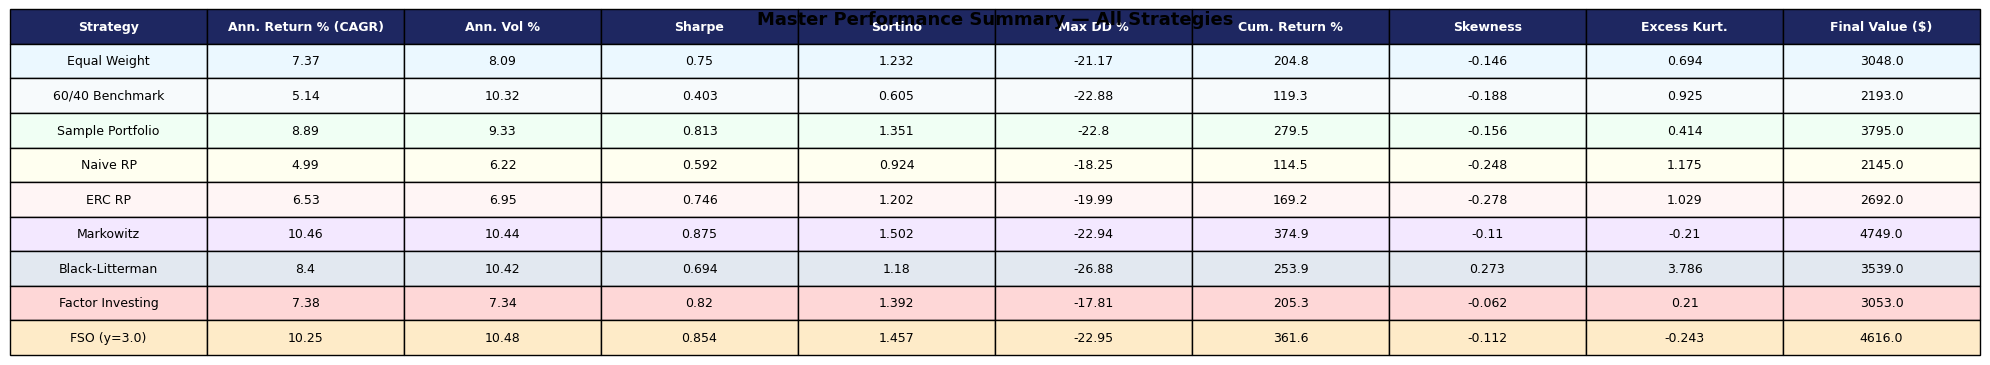

In [25]:
# Align all strategies to the rolling strategies' common start date
comparison_period = sim['ERC RP'].index
for k in ['Equal Weight', '60/40 Benchmark', 'Sample Portfolio', 'Naive RP']:
    sim[k] = sim[k].loc[comparison_period]

avg_rf_annual  = annual_rf_series.reindex(comparison_period, method='ffill').mean()
avg_rf_monthly = monthly_rf_series.reindex(comparison_period, method='ffill').mean()

print(f'Comparison period : {comparison_period[0].date()} -> {comparison_period[-1].date()}')
print(f'Months            : {len(comparison_period)}')
print(f'RF (aligned)      : {avg_rf_annual*100:.3f}% annual  |  {avg_rf_monthly*100:.4f}% monthly')

summary = pd.DataFrame([
    compute_stats(ret, label, avg_rf_monthly, avg_rf_annual, initial_investment)
    for label, ret in sim.items()
])

print('=' * 80)
print('MASTER PERFORMANCE TABLE')
print('=' * 80)
print(summary.to_string())
print()
print('Note: Ann. Return is true geometric CAGR: (product(1+r_t))^(12/T) - 1.')
print('      Sortino uses full-sample downside deviation [Sortino & van der Meer, 1991].')
print(f'      FSO vol-constrained to {VOL_TARGET*100:.0f}% ann. vol (same as Markowitz) — fair comparison.')

fig, ax = plt.subplots(figsize=(20, 3.8))
ax.axis('off')
col_labels = ['Strategy'] + list(summary.columns)
row_data   = [[idx] + [str(v) for v in summary.loc[idx]] for idx in summary.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 2.2)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
row_colors = ['#EBF8FF','#F7FAFC','#F0FFF4','#FFFFF0','#FFF5F5',
              '#F3E8FF','#E2E8F0','#FED7D7','#FEEBC8']
for i, color in enumerate(row_colors, start=1):
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(color)
ax.set_title('Master Performance Summary — All Strategies',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()


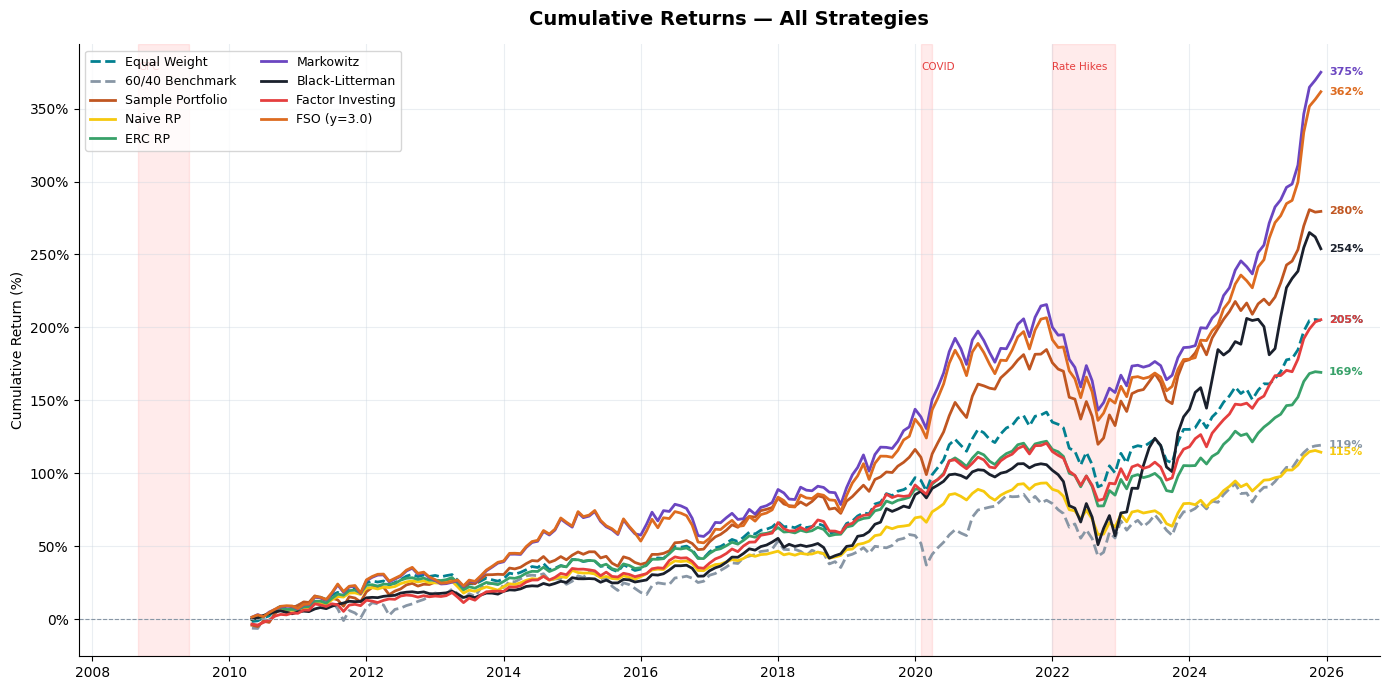

In [26]:
fig, ax = plt.subplots(figsize=(14, 7))
for label, ret in sim.items():
    cum = ((1 + ret).cumprod() - 1) * 100
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    ax.plot(cum, label=label, color=PALETTE[label], linewidth=2, linestyle=ls)
    ax.annotate(
        f'{cum.iloc[-1]:.0f}%',
        xy=(cum.index[-1], cum.iloc[-1]),
        xytext=(6, 0), textcoords='offset points',
        color=PALETTE[label], fontsize=8, fontweight='bold', va='center',
    )
for s, e, lbl in CRISES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red', zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[1]*0.97, lbl,
            fontsize=7.5, color='#E53E3E', va='top')
ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Returns — All Strategies', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()


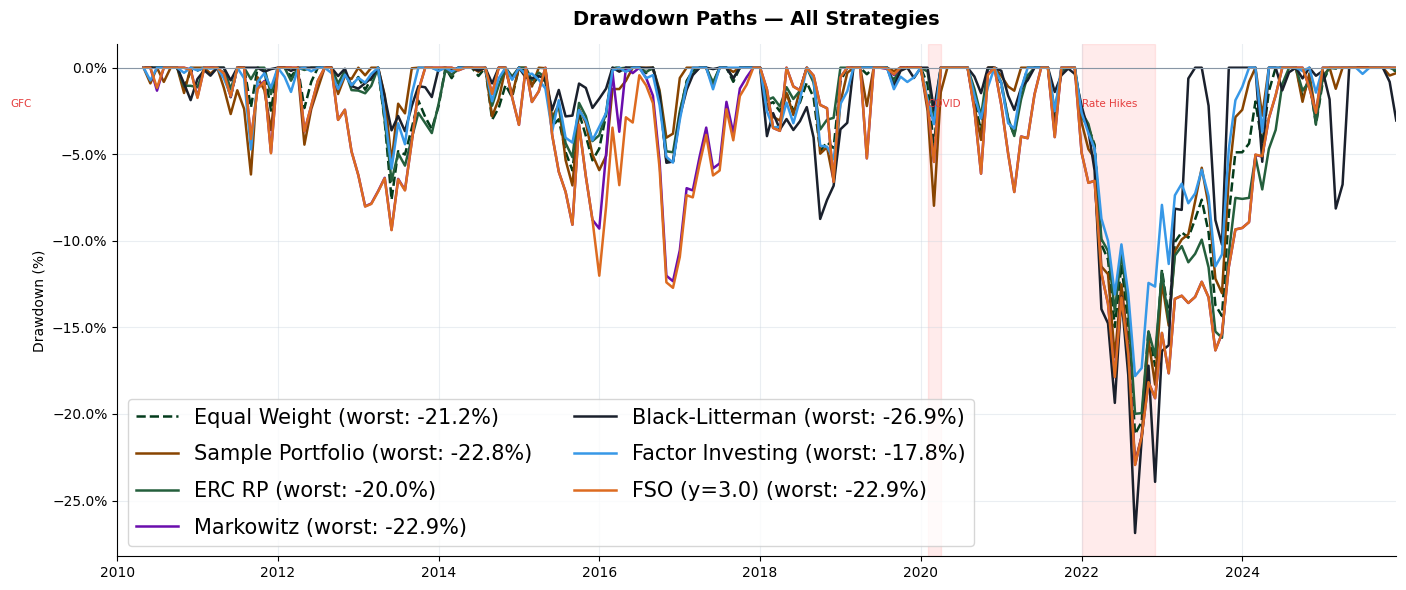

In [49]:
keep = [
    'Equal Weight', 'Sample Portfolio', 'Markowitz', 'ERC RP',
    'Black-Litterman', 'Factor Investing', 'FSO (y=3.0)'
]

fig, ax = plt.subplots(figsize=(14, 6))
for label, ret in sim.items():
    if label not in keep:
        continue

    cum = (1 + ret).cumprod()
    dd  = ((cum - cum.cummax()) / cum.cummax()) * 100
    ls  = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    ax.plot(dd, label=f'{label} (worst: {dd.min():.1f}%)',
            color=PALETTE[label], linewidth=1.8, linestyle=ls)
for s, e, lbl in CRISES:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.08, color='red', zorder=0)
    ax.text(pd.Timestamp(s), ax.get_ylim()[0]*0.08, lbl,
            fontsize=7.5, color='#E53E3E')
ax.axhline(0, color='#8896A5', linewidth=0.8)
ax.set_xlim(pd.Timestamp('2010-01-01'), dd.index[-1])
ax.set_title('Drawdown Paths — All Strategies', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='lower left', ncol=2, fontsize=15, frameon=True, labelspacing=0.8)
plt.tight_layout(); plt.show()


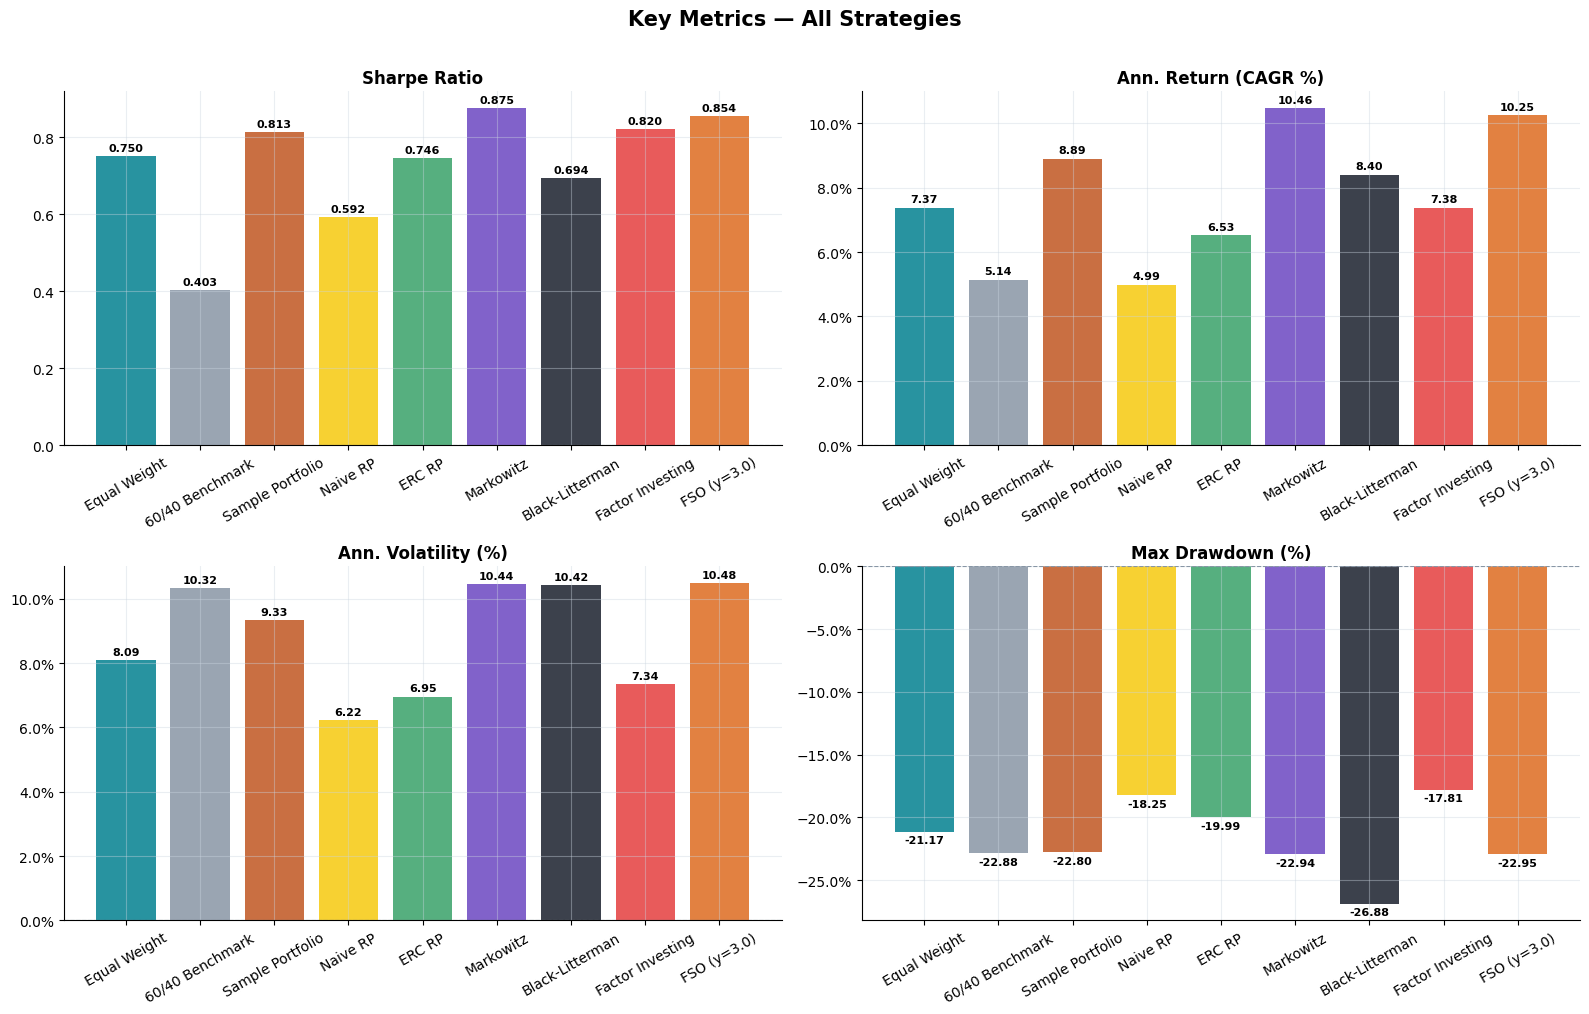

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels_all = list(sim.keys())
colors_all = [PALETTE[l] for l in labels_all]

def bar_chart(ax, metric, title, fmt='{:.2f}', pct=False):
    vals = summary[metric]
    bars = ax.bar(vals.index, vals.values, color=colors_all, alpha=0.85)
    ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals.values):
        off = 0.01 * (vals.abs().max() or 1) * (1 if v >= 0 else -1)
        ax.text(bar.get_x() + bar.get_width()/2, v + off,
                fmt.format(v), ha='center',
                va='bottom' if v >= 0 else 'top',
                fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    if pct: ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)

bar_chart(axes[0, 0], 'Sharpe',              'Sharpe Ratio',           '{:.3f}')
bar_chart(axes[0, 1], 'Ann. Return % (CAGR)','Ann. Return (CAGR %)',   '{:.2f}', pct=True)
bar_chart(axes[1, 0], 'Ann. Vol %',          'Ann. Volatility (%)',    '{:.2f}', pct=True)
bar_chart(axes[1, 1], 'Max DD %',            'Max Drawdown (%)',       '{:.2f}', pct=True)

fig.suptitle('Key Metrics — All Strategies', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


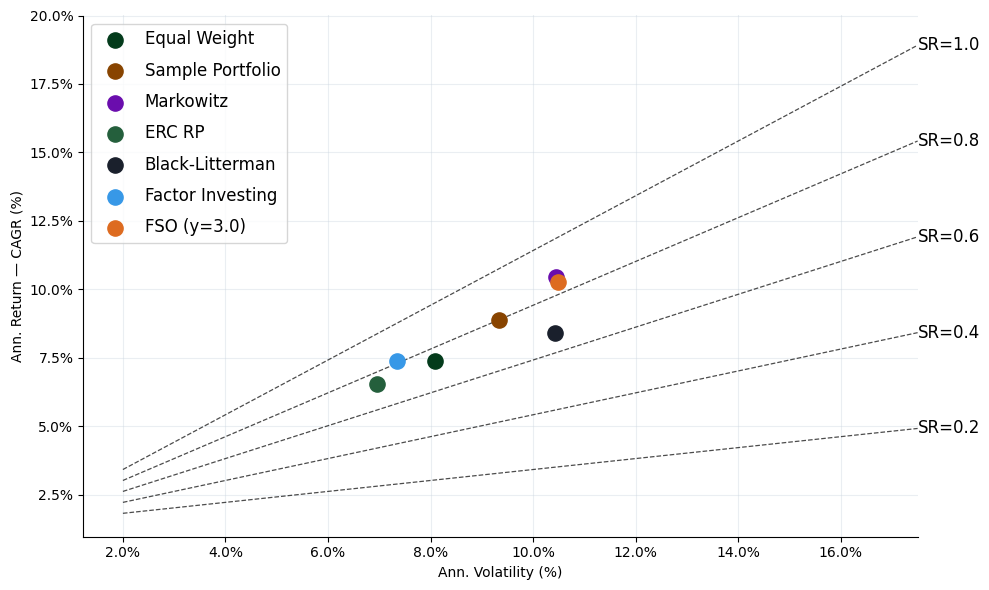

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))

# Focus on core strategies for cleaner comparison
keep = [
    'Equal Weight', 'Sample Portfolio', 'Markowitz', 'ERC RP',
    'Black-Litterman', 'Factor Investing', 'FSO (y=3.0)'
]

vols_range = np.linspace(2, 17.5, 200)
for sr in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(vols_range,
            avg_rf_annual * 100 + sr * vols_range,
            '--', color='#000', linewidth=0.9, alpha=0.7)
    ax.text(vols_range[-1],
            avg_rf_annual * 100 + sr * vols_range[-1],
            f'SR={sr:.1f}', fontsize=12, color='#000', va='center')

for label in keep:
    x = summary.loc[label, 'Ann. Vol %']
    y = summary.loc[label, 'Ann. Return % (CAGR)']
    ax.scatter(x, y, color=PALETTE[label], s=120, zorder=5, label=label)

ax.set_xlabel('Ann. Volatility (%)')
ax.set_ylabel('Ann. Return — CAGR (%)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(right=17.5)
ax.set_ylim(top=20)
ax.legend(loc='upper left', fontsize=12, frameon=True, labelspacing=0.8)
# ax.set_title('Risk-Return Scatter (dashed = iso-Sharpe lines)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()


In [30]:
print('=' * 80)
print('CRISIS RECOVERY TABLE (months from trough back to pre-crisis peak)')
print('=' * 80)
header = f"{'':20}" + ''.join(f"{l:>18}" for l in sim)
print(header)
print('-' * len(header))
for cs, ce, clbl in CRISES:
    row = f"{clbl:20}"
    for label, ret in sim.items():
        m = months_to_recover(ret, cs, ce)
        row += f"{'N/A':>18}" if m is None else f"{str(m)+'m':>18}"
    print(row)
print()
print('N/A = never recovered within data, or crisis predates the 36-month warm-up window.')
print('GFC: all rolling strategies start May-2010, after the Mar-2009 trough.')


CRISIS RECOVERY TABLE (months from trough back to pre-crisis peak)
                          Equal Weight   60/40 Benchmark  Sample Portfolio          Naive RP            ERC RP         Markowitz   Black-Litterman  Factor Investing       FSO (y=3.0)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
GFC                                N/A               N/A               N/A               N/A               N/A               N/A               N/A               N/A               N/A
COVID                               1m                5m                2m                1m                1m                1m                1m                1m                1m
Rate Hikes                         21m               23m               18m               24m               23m               22m                9m               17m               22m

N/A = never recov

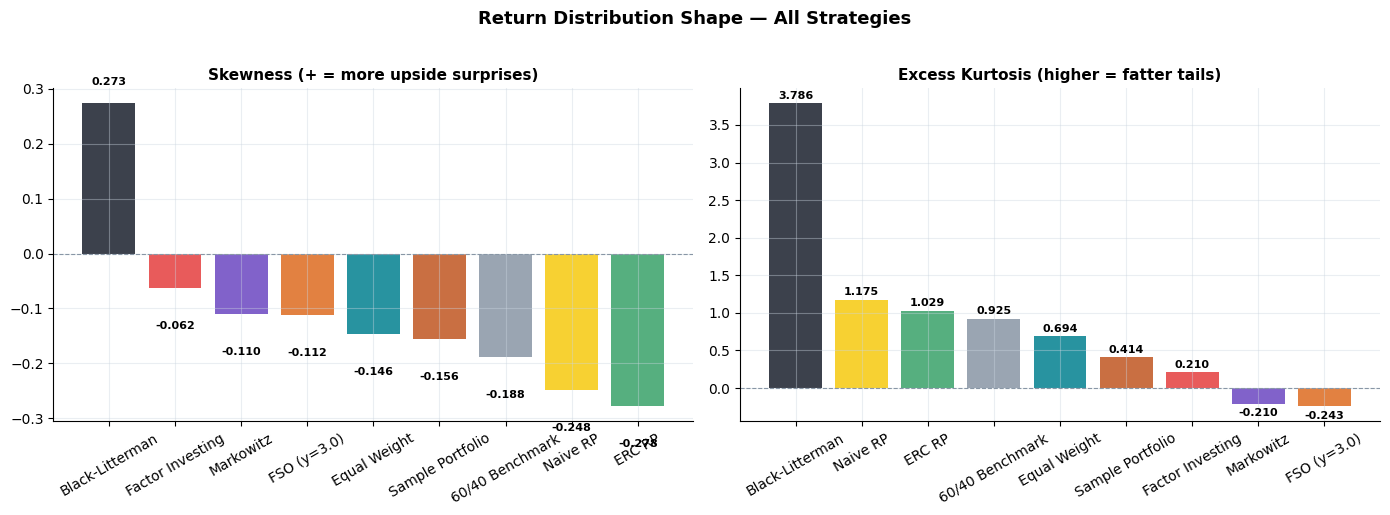


-- Distribution Statistics --
                  Skewness  Excess Kurt.
Equal Weight        -0.146         0.694
60/40 Benchmark     -0.188         0.925
Sample Portfolio    -0.156         0.414
Naive RP            -0.248         1.175
ERC RP              -0.278         1.029
Markowitz           -0.110        -0.210
Black-Litterman      0.273         3.786
Factor Investing    -0.062         0.210
FSO (y=3.0)         -0.112        -0.243

Black-Litterman is the only strategy with positive skewness: asymmetric upside.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title in [
    (axes[0], 'Skewness',     'Skewness (+ = more upside surprises)'),
    (axes[1], 'Excess Kurt.', 'Excess Kurtosis (higher = fatter tails)'),
]:
    vals  = summary[metric].sort_values(ascending=False)
    cols  = [PALETTE[l] for l in vals.index]
    bars  = ax.bar(vals.index, vals.values, color=cols, alpha=0.85)
    ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + (0.03 if v >= 0 else -0.06),
                f'{v:.3f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
fig.suptitle('Return Distribution Shape — All Strategies',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n-- Distribution Statistics --')
print(summary[['Skewness','Excess Kurt.']].to_string())
print()
print('Black-Litterman is the only strategy with positive skewness: asymmetric upside.')


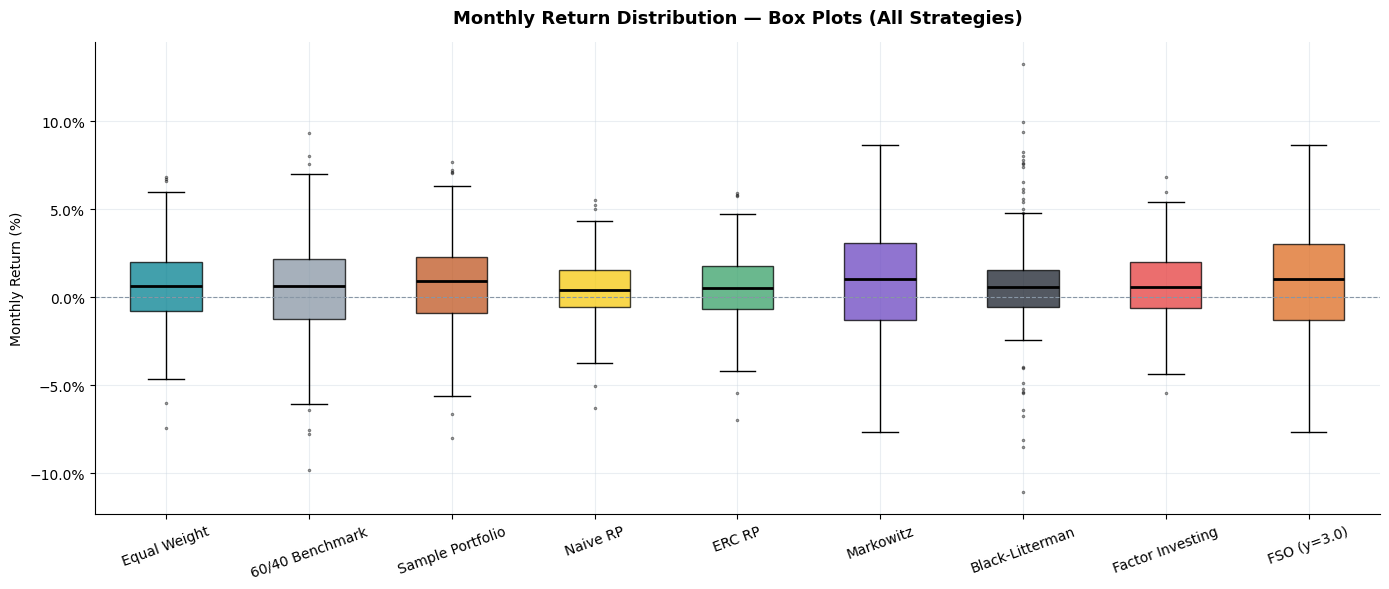

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(
    [sim[l].values * 100 for l in sim],
    labels=list(sim.keys()),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', markersize=3, alpha=0.5),
)
for patch, lbl in zip(bp['boxes'], sim):
    patch.set_facecolor(PALETTE[lbl])
    patch.set_alpha(0.75)
ax.axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
ax.set_ylabel('Monthly Return (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Monthly Return Distribution — Box Plots (All Strategies)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


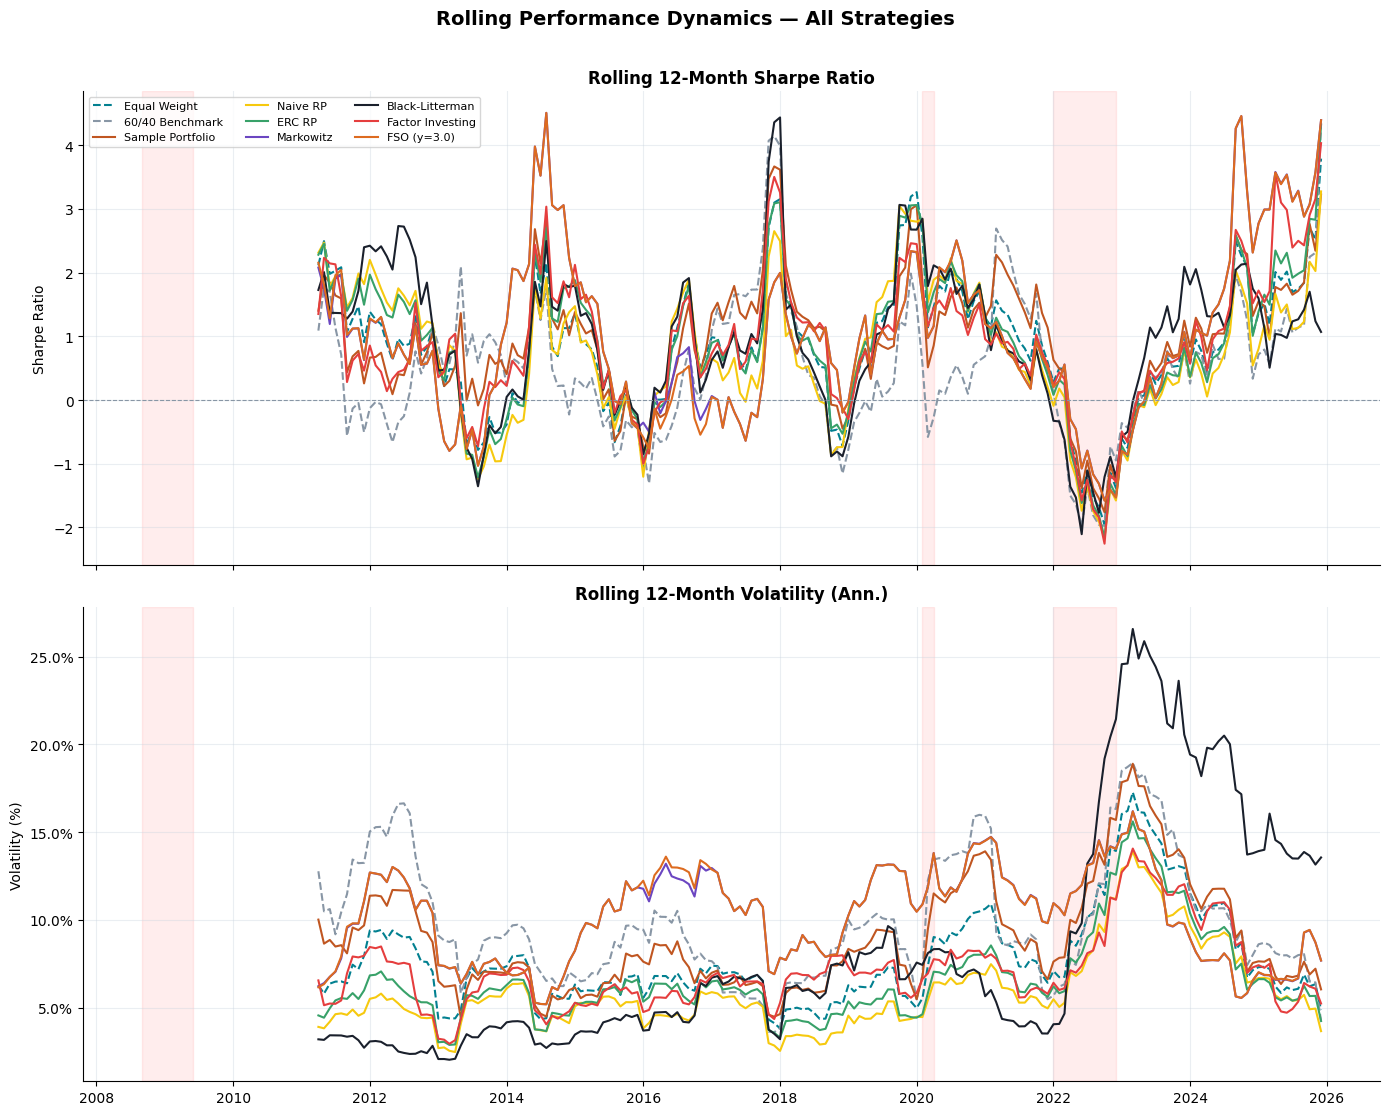

In [33]:
ROLL_W = 12
fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
for label, ret in sim.items():
    roll_sr  = (ret.rolling(ROLL_W).mean() - avg_rf_monthly) * 12 / \
               (ret.rolling(ROLL_W).std() * np.sqrt(12))
    roll_vol = ret.rolling(ROLL_W).std() * np.sqrt(12) * 100
    ls = '--' if label in ('Equal Weight', '60/40 Benchmark') else '-'
    axes[0].plot(roll_sr,  label=label, color=PALETTE[label], linewidth=1.5, linestyle=ls)
    axes[1].plot(roll_vol, label=label, color=PALETTE[label], linewidth=1.5, linestyle=ls)
for ax in axes:
    for s, e, lbl in CRISES:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.07, color='red', zorder=0)
axes[0].axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
axes[0].set_title(f'Rolling {ROLL_W}-Month Sharpe Ratio',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[1].set_title(f'Rolling {ROLL_W}-Month Volatility (Ann.)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Volatility (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(fontsize=8, ncol=3, loc='upper left')
fig.suptitle('Rolling Performance Dynamics — All Strategies',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


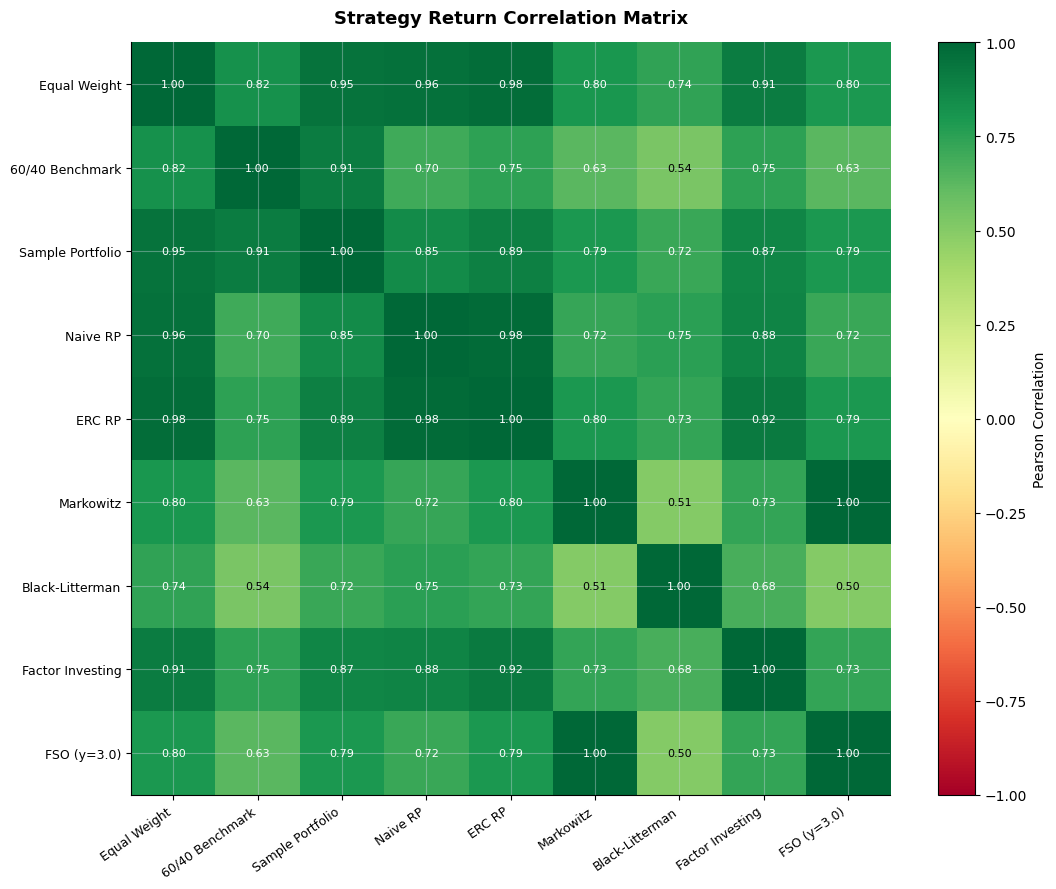

In [34]:
ret_df  = pd.DataFrame(sim)
corr_df = ret_df.corr()
n_s     = len(sim)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_df.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_xticks(range(n_s)); ax.set_yticks(range(n_s))
ax.set_xticklabels(corr_df.columns, rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(corr_df.index, fontsize=9)
for i in range(n_s):
    for j in range(n_s):
        v = corr_df.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Strategy Return Correlation Matrix',
             fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()


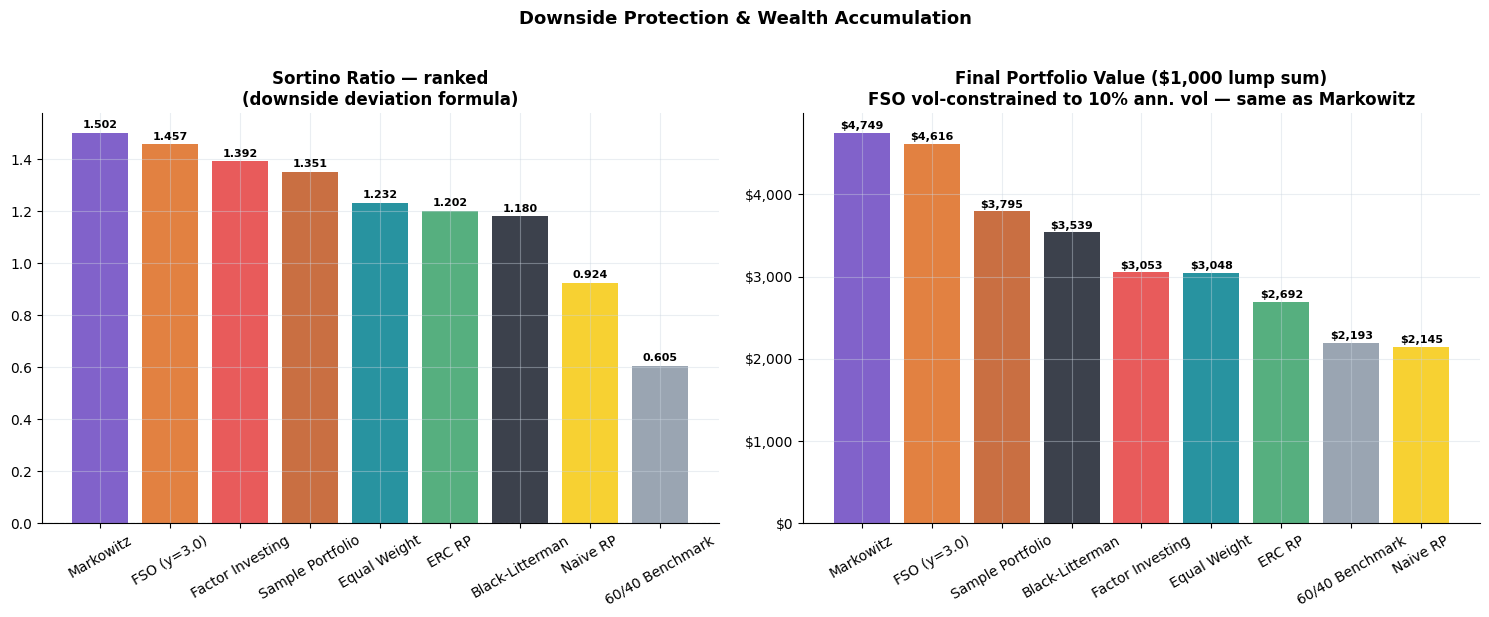

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

so_vals = summary['Sortino'].sort_values(ascending=False)
c_so    = [PALETTE[l] for l in so_vals.index]
bars = axes[0].bar(so_vals.index, so_vals.values, color=c_so, alpha=0.85)
for bar, v in zip(bars, so_vals.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].axhline(0, color='#8896A5', linewidth=0.8, linestyle='--')
axes[0].set_title('Sortino Ratio — ranked\n(downside deviation formula)',
                   fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

fv_vals = summary['Final Value ($)'].sort_values(ascending=False)
c_fv    = [PALETTE[l] for l in fv_vals.index]
bars2   = axes[1].bar(fv_vals.index, fv_vals.values, color=c_fv, alpha=0.85)
for bar, v in zip(bars2, fv_vals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 20,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title(
    f'Final Portfolio Value (${initial_investment:,.0f} lump sum)\n'
    f'FSO vol-constrained to {VOL_TARGET*100:.0f}% ann. vol — same as Markowitz',
    fontsize=12, fontweight='bold',
)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Downside Protection & Wealth Accumulation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


STRATEGY RANKING  (1 = best per metric, sorted by average rank)
                  Return  Vol  Sharpe  Sortino  Max DD  Avg Rank
Factor Investing       5    3       3        3       1       3.0
Markowitz              1    8       1        1       7       3.6
Sample Portfolio       3    5       4        4       5       4.2
FSO (y=3.0)            2    9       2        2       8       4.6
ERC RP                 7    2       6        6       3       4.8
Equal Weight           6    4       5        5       4       4.8
Naive RP               9    1       8        8       2       5.6
Black-Litterman        4    7       7        7       9       6.8
60/40 Benchmark        8    6       9        9       6       7.6

Overall winner: Factor Investing  (avg rank 3.0)


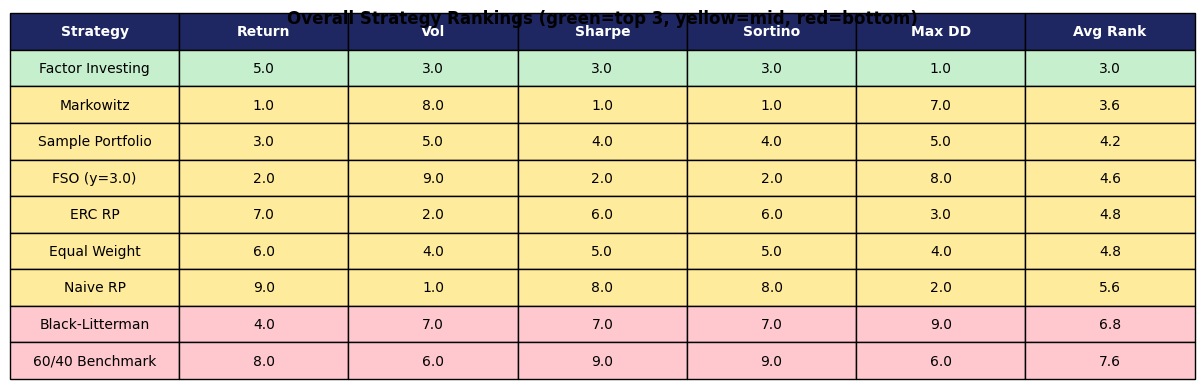

In [36]:
rank_df = pd.DataFrame(index=summary.index)
rank_df['Return']  = summary['Ann. Return % (CAGR)'].rank(ascending=False).astype(int)
rank_df['Vol']     = summary['Ann. Vol %'].rank(ascending=True).astype(int)
rank_df['Sharpe']  = summary['Sharpe'].rank(ascending=False).astype(int)
rank_df['Sortino'] = summary['Sortino'].rank(ascending=False).astype(int)
rank_df['Max DD']  = summary['Max DD %'].rank(ascending=False).astype(int)
rank_df['Avg Rank']= rank_df.mean(axis=1).round(1)
rank_df = rank_df.sort_values('Avg Rank')

print('=' * 70)
print('STRATEGY RANKING  (1 = best per metric, sorted by average rank)')
print('=' * 70)
print(rank_df.to_string())
print()
print(f'Overall winner: {rank_df.index[0]}  (avg rank {rank_df["Avg Rank"].iloc[0]})')

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
col_labels = ['Strategy'] + list(rank_df.columns)
row_data   = [[idx] + [str(v) for v in rank_df.loc[idx]] for idx in rank_df.index]
tbl = ax.table(cellText=row_data, colLabels=col_labels, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.1, 2.2)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1E2761')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i, lbl in enumerate(rank_df.index, start=1):
    color = '#C6EFCE' if rank_df.loc[lbl,'Avg Rank'] <= 3 else \
            '#FFEB9C' if rank_df.loc[lbl,'Avg Rank'] <= 6 else '#FFC7CE'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(color)
ax.set_title('Overall Strategy Rankings (green=top 3, yellow=mid, red=bottom)',
             fontsize=12, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()


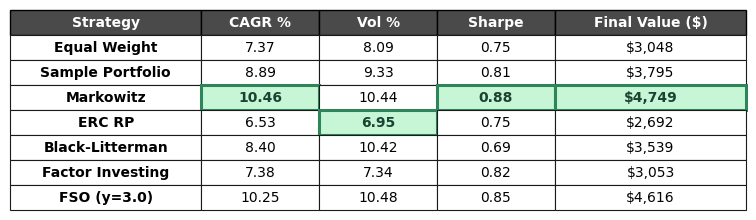

In [71]:
# Compact summary table for the main strategies shown in the report
table_order = [
    'Equal Weight',
    'Sample Portfolio',
    'Markowitz',
    'ERC RP',
    'Black-Litterman',
    'Factor Investing',
    'FSO (y=3.0)'
]

table_df = summary.loc[table_order, ['Ann. Return % (CAGR)', 'Ann. Vol %', 'Sharpe', 'Final Value ($)']].copy()
table_df.columns = ['CAGR %', 'Vol %', 'Sharpe', 'Final Value ($)']

fig, ax = plt.subplots(figsize=(9.5, 2.6))
ax.axis('off')

display_df = table_df.reset_index().rename(columns={'index': 'Strategy'})
display_df['CAGR %'] = display_df['CAGR %'].map(lambda v: f'{v:.2f}')
display_df['Vol %'] = display_df['Vol %'].map(lambda v: f'{v:.2f}')
display_df['Sharpe'] = display_df['Sharpe'].map(lambda v: f'{v:.2f}')
display_df['Final Value ($)'] = display_df['Final Value ($)'].map(lambda v: f'${v:,.0f}')

tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    cellLoc='center',
    loc='center',
    colWidths=[0.26, 0.16, 0.16, 0.16, 0.26],
    bbox=[0, 0, 1, 1],
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.35)

for j in range(len(display_df.columns)):
    tbl[0, j].set_facecolor('#4a4a4a')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(display_df) + 1):
    for j in range(len(display_df.columns)):
        tbl[i, j].set_facecolor("#fff")
        tbl[i, j].set_edgecolor('#1a1a1a')
        tbl[i, j].set_linewidth(0.8)
        if j == 0:
            tbl[i, j].set_text_props(fontweight='bold')

best_cagr_label = table_df['CAGR %'].idxmax()
best_vol_label = table_df['Vol %'].idxmin()
best_sharpe_label = table_df['Sharpe'].idxmax()
best_final_label = table_df['Final Value ($)'].idxmax()

best_lookup = {
    'CAGR %': best_cagr_label,
    'Vol %': best_vol_label,
    'Sharpe': best_sharpe_label,
    'Final Value ($)': best_final_label,
}

for metric_idx, metric_name in enumerate(['CAGR %', 'Vol %', 'Sharpe', 'Final Value ($)'], start=1):
    best_label = best_lookup[metric_name]
    row_pos = table_df.index.get_loc(best_label) + 1
    cell = tbl[row_pos, metric_idx]
    cell.set_facecolor('#C6F6D5')
    cell.set_edgecolor('#2F855A')
    cell.set_linewidth(2.2)
    cell.set_text_props(color='#1B4332', fontweight='bold')

plt.show()
